# Метрики и режимы обучения, участник 1 (UPDATED 2026-06-02 01:16)

Этот ноутбук отдельная лаборатория продуктовых метрик и режимов обучения для session level регрессии. Здесь не делаем сложный feature engineering, а проверяем как меняется качество и продуктовый риск при разных целях обучения.

## Почему одного MAE мало

MAE хорошо отражает среднюю ошибку, но плохо показывает поведение на длинных сессиях и эффект тяжелого хвоста. Поэтому нужно смотреть и базовые метрики из preprocessing, и дополнительные регрессионные метрики по масштабу ошибки и хвостовой чувствительности.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

from sklearn.base import clone

repo_root = Path.cwd()
if repo_root.name != 'ml_in_gamedev_project':
    for p in [repo_root, *repo_root.parents]:
        if p.name == 'ml_in_gamedev_project':
            repo_root = p
            break
sys.path.append(str(repo_root))

from catboost import CatBoostRegressor, CatBoostClassifier
from preprocessing.preprocessing import (
    load_data,
    prepare_for_targets,
    regression_metrics,
    TargetTransform,
)

pd.set_option('display.max_columns', 200)

## Данные и таргеты

Работаем только с двумя основными таргетами, которые были выбраны в предыдущем ноутбуке.

In [2]:
target_cols = [
    'target_next_session_length_sec',
    'future_sessions_mean_playtime_7d',
]

df = load_data()
packs = prepare_for_targets(df, target_cols=target_cols, max_rows=60000)

pd.DataFrame([
    {
        'target': t,
        'train_rows': len(p.x_train),
        'val_rows': len(p.x_val),
        'test_rows': len(p.x_test),
        'num_cols': len(p.num_cols),
        'cat_cols': len(p.cat_cols),
    }
    for t, p in packs.items()
])

,target,train_rows,val_rows,test_rows,num_cols,cat_cols
0,target_next_session_length_sec,42000,9000,9000,59,14
1,future_sessions_mean_playtime_7d,42000,9000,9000,59,14


## Набор метрик

Считаем все метрики из preprocessing, затем добавляем две дополнительные регрессионные метрики: WMAPE и кастомный TailWeightedMAE. Они дополняют картину по масштабу ошибки и чувствительности к длинным сессиям.

WMAPE - это суммарная абсолютная ошибка, делённая на суммарное реальное значение. Показывает, на сколько процентов модель ошибается относительно общего объёма; большие значения сильнее влияют на метрику.

TailWeightedMAE — кастомная MAE, где ошибки на хвосте распределения, то есть на больших/редких/важных значениях, получают больший вес. Нужна, чтобы сильнее штрафовать модель за промахи на крупных случаях, а не только за среднюю ошибку по всем объектам.

In [3]:
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    den = np.abs(y_true).sum()
    if den <= 0:
        return np.nan
    return float(np.abs(y_true - y_pred).sum() / den)

def tail_weighted_mae(y_true, y_pred, split_q=0.9, tail_w=2.0):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    ae = np.abs(yp - yt)
    thr = np.quantile(yt, split_q)
    w = np.where(yt >= thr, tail_w, 1.0)
    return float(np.sum(w * ae) / np.sum(w))

def full_metric_dict(y_true, y_pred):
    base = regression_metrics(y_true, y_pred)
    extra = {
        'wmape': wmape(y_true, y_pred),
        'tail_weighted_mae_q90_w2': tail_weighted_mae(y_true, y_pred, split_q=0.9, tail_w=2.0),
    }
    return {**base, **extra}


## Режимы обучения

Сравним несколько кастомных стратегий

У таргета тяжелый хвост и обычный MAE начинает переобучаться на редкие экстремальные сессии. Поэтому я придумал несколько статегий покрывают разные продуктовые риски: консервативные квантильные режимы снижают переоценку, capped/weighted варианты стабилизируют обучение на основной массе (тк экстремальные значения хвоста непропорционально тянут лосс), а базовые train_mae и train_quantile_05 дают честную точку сравнения для интерпретации выигрышей

train_engagement_quantile_030_postcap - квантиль 0.30 с пост-капом, максимально консервативный прогноз  
train_engagement_quantile_035 - квантиль 0.35, сильнее штрафует переоценку  
train_overprediction_aware - MAE-модель со shrink предсказаний для снижения overpredict  
train_quantile_04 - квантиль 0.40, консервативнее медианы  
train_below_cap_only - обучение по основной массе, хвост выше капа выключен  
train_capped_target - обучение на таргете, обрезанном по p995  
train_engagement_weighted_mae - взвешенный MAE с приоритетом коротких сессий  
train_tail_downweight - мягкий штраф для сверхдлинного хвоста  
train_mae - базовый CatBoost с обычным MAE  
train_quantile_05 - квантиль 0.50, медианный робастный baseline

In [4]:
mode_defs = [
    {'mode': 'train_engagement_quantile_030_postcap', 'kind': 'quantile_postcap', 'alpha': 0.30},
    {'mode': 'train_engagement_quantile_035', 'kind': 'quantile_loss', 'alpha': 0.35},
    {'mode': 'train_overprediction_aware', 'kind': 'overprediction_aware', 'shrink': 0.92},
    {'mode': 'train_quantile_04', 'kind': 'quantile_loss', 'alpha': 0.40},
    {'mode': 'train_below_cap_only', 'kind': 'below_cap_only'},
    {'mode': 'train_capped_target', 'kind': 'transform', 'transform': 'p995'},
    {'mode': 'train_engagement_weighted_mae', 'kind': 'engagement_weighted'},
    {'mode': 'train_tail_downweight', 'kind': 'tail_downweight'},
    {'mode': 'train_mae', 'kind': 'plain_mae'},
    {'mode': 'train_quantile_05', 'kind': 'quantile_loss', 'alpha': 0.50},
]

param_grid = [
    {'depth': 5, 'learning_rate': 0.06, 'l2_leaf_reg': 3},
    {'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 5},
]

base_reg = dict(
    iterations=300,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    verbose=False,
)


In [5]:
def make_weights(y, kind, d):
    y = np.asarray(y, dtype=float)
    w = np.ones_like(y, dtype=float)
    cap = np.quantile(y, 0.995)
    if kind == 'engagement_weighted':
        w = np.where(y <= 300, 1.5, np.where(y <= 1200, 1.0, 0.2))
    if kind == 'tail_downweight':
        w = np.where(y > cap, 0.3, 1.0)
    if kind == 'below_cap_only':
        w = np.where(y <= cap, 1.0, 0.0)
    return w

def fit_predict_one_mode(p, mdef, hp):
    xtr, xva, xte = p.x_train, p.x_val, p.x_test
    ytr, yva, yte = p.y_train, p.y_val, p.y_test
    cat_cols = p.cat_cols

    if mdef['kind'] == 'transform':
        tfm = TargetTransform(mode=mdef['transform']).fit(ytr)
        yfit = tfm.transform(ytr)
        reg = CatBoostRegressor(**base_reg, **hp)
        reg.fit(xtr, yfit, cat_features=cat_cols)
        pred_tr = tfm.inverse(reg.predict(xtr))
        pred_va = tfm.inverse(reg.predict(xva))
        pred_te = tfm.inverse(reg.predict(xte))
        return pred_tr, pred_va, pred_te

    reg_params = dict(base_reg)
    if mdef['kind'] in ('quantile_loss', 'quantile_postcap'):
        reg_params['loss_function'] = f"Quantile:alpha={mdef['alpha']:.2f}"

    reg = CatBoostRegressor(**reg_params, **hp)
    w = make_weights(ytr, mdef['kind'], mdef)
    reg.fit(xtr, ytr, cat_features=cat_cols, sample_weight=w)

    pred_tr = np.maximum(reg.predict(xtr), 0.0)
    pred_va = np.maximum(reg.predict(xva), 0.0)
    pred_te = np.maximum(reg.predict(xte), 0.0)

    if mdef['kind'] == 'overprediction_aware':
        k = mdef.get('shrink', 0.92)
        pred_tr = pred_tr * k
        pred_va = pred_va * k
        pred_te = pred_te * k

    if mdef['kind'] == 'quantile_postcap':
        cap = np.quantile(ytr, 0.995)
        pred_tr = np.minimum(pred_tr, cap)
        pred_va = np.minimum(pred_va, cap)
        pred_te = np.minimum(pred_te, cap)

    return pred_tr, pred_va, pred_te


## Экспериментальный протокол

На каждый таргет и каждый режим запускаем небольшой одинаковый перебор гиперпараметров и сравниваем val и test метрики в единой сводной таблице.

In [6]:
rows = []
for t, p in packs.items():
    for m in mode_defs:
        for hp in param_grid:
            pr_tr, pr_va, pr_te = fit_predict_one_mode(p, m, hp)
            mt_tr = full_metric_dict(p.y_train, pr_tr)
            mt_va = full_metric_dict(p.y_val, pr_va)
            mt_te = full_metric_dict(p.y_test, pr_te)
            r = {
                'target': t,
                'mode': m['mode'],
                'depth': hp['depth'],
                'lr': hp['learning_rate'],
                'l2': hp['l2_leaf_reg'],
            }
            for k, v in mt_tr.items():
                r['train_' + k] = v
            for k, v in mt_va.items():
                r['val_' + k] = v
            for k, v in mt_te.items():
                r['test_' + k] = v
            rows.append(r)

res = pd.DataFrame(rows).sort_values(['target', 'val_mae']).reset_index(drop=True)
res.head(20)

,target,mode,depth,lr,l2,train_mae,train_medae,train_p70_abs_error,train_p90_abs_error,train_r2,train_product_mae,train_engagement_risk_mae,train_small_mae,train_normal_mae,train_long_mae,train_wmape,train_tail_weighted_mae_q90_w2,val_mae,val_medae,val_p70_abs_error,val_p90_abs_error,val_r2,val_product_mae,val_engagement_risk_mae,val_small_mae,val_normal_mae,val_long_mae,val_wmape,val_tail_weighted_mae_q90_w2,test_mae,test_medae,test_p70_abs_error,test_p90_abs_error,test_r2,test_product_mae,test_engagement_risk_mae,test_small_mae,test_normal_mae,test_long_mae,test_wmape,test_tail_weighted_mae_q90_w2
0,future_sessions_mean_playtime_7d,train_below_cap_only,6,0.05,5,252.323166,127.360512,262.157544,591.397805,0.346034,176.547627,181.128685,190.047497,163.369642,899.675207,0.422655,315.152876,274.354615,151.741563,284.081276,615.053238,0.287709,191.838261,196.234021,192.546211,188.338556,961.747380,0.456492,340.466023,269.552671,159.764827,281.627944,623.376304,0.255936,202.125608,206.679935,224.591306,183.980521,935.681895,0.467923,328.883811
1,future_sessions_mean_playtime_7d,train_tail_downweight,6,0.05,5,252.727063,128.159504,264.033531,591.925752,0.349678,176.793247,181.560986,190.441281,163.839162,899.766178,0.423332,315.515745,274.564576,151.345085,284.272222,618.321378,0.286679,191.314624,195.987648,192.246348,188.074300,965.922050,0.456842,341.014264,268.805451,159.648574,283.161095,615.845222,0.267492,200.624739,205.994999,222.785196,184.191689,932.416871,0.466626,327.936131
2,future_sessions_mean_playtime_7d,train_capped_target,6,0.05,5,253.161929,129.334977,263.697332,592.590742,0.349096,177.812560,182.597112,192.554659,164.031759,896.535831,0.424060,315.588600,274.740319,152.142258,282.423266,618.405958,0.287602,191.670946,196.605015,195.071448,186.803434,965.676677,0.457134,341.138441,269.086104,157.612844,280.176379,622.672908,0.262724,201.367804,206.698425,226.625832,182.468576,933.703392,0.467113,328.270725
3,future_sessions_mean_playtime_7d,train_mae,6,0.05,5,253.838111,129.711207,264.214625,592.350987,0.347634,178.415763,183.104613,192.797025,164.743943,898.298254,0.425193,316.377728,274.779852,151.275655,283.574850,616.626260,0.288661,192.777461,196.819739,194.673634,187.584563,963.191101,0.457200,340.948533,269.833491,158.102819,280.632312,621.301302,0.262834,201.835123,207.304245,226.210585,183.863624,934.163529,0.468411,329.006403
4,future_sessions_mean_playtime_7d,train_quantile_05,6,0.05,5,253.838111,129.711207,264.214625,592.350987,0.347634,178.415763,183.104613,192.797025,164.743943,898.298254,0.425193,316.377728,274.779852,151.275655,283.574850,616.626260,0.288661,192.777461,196.819739,194.673634,187.584563,963.191101,0.457200,340.948533,269.833491,158.102819,280.632312,621.301302,0.262834,201.835123,207.304245,226.210585,183.863624,934.163529,0.468411,329.006403
5,future_sessions_mean_playtime_7d,train_below_cap_only,5,0.06,3,256.562412,131.650686,267.013950,596.456616,0.335652,179.884358,184.802464,193.458548,167.189899,908.534612,0.429756,319.796223,275.629272,154.317086,283.881288,618.571519,0.284851,193.771304,197.477975,192.913475,190.352985,961.905504,0.458613,341.651101,270.834887,159.427686,285.300023,622.864456,0.257107,202.746044,207.928733,224.348965,186.405369,934.791411,0.470149,329.979115
6,future_sessions_mean_playtime_7d,train_capped_target,5,0.06,3,257.762610,132.690875,269.335970,599.695068,0.337973,181.668428,186.447821,196.250460,167.909907,907.566751,0.431767,320.825590,275.897541,154.723014,285.377927,617.186274,0.283376,192.373326,196.842967,193.135669,188.831363,971.547485,0.459060,342.729921,269.915371,158.545860,283.833877,617.355505,0.262151,200.866025,206.717900,223.984187,184.485219,938.243190,0.468553,329.453361
7,future_sessions_mean_playtime_7d,train_tail_downweight,5,0.06,3,257.568070,133.221598,269.819161,596.530525,0.336347,180.409169,185.438362,193.373250,168.395154,911.702501,0.431441,321.014590,275.948012,154.164003,288.291833,612.960720,0.285632,192.730081,197.384

In [7]:
main_cols = [
    'target', 'mode', 'depth', 'lr', 'l2',
    'val_mae', 'test_mae', 'val_r2', 'test_r2',
    'val_product_mae', 'test_product_mae',
    'val_engagement_risk_mae', 'test_engagement_risk_mae',
    'val_wmape', 'test_wmape',
    'val_tail_weighted_mae_q90_w2', 'test_tail_weighted_mae_q90_w2',
]
res[main_cols]

,target,mode,depth,lr,l2,val_mae,test_mae,val_r2,test_r2,val_product_mae,test_product_mae,val_engagement_risk_mae,test_engagement_risk_mae,val_wmape,test_wmape,val_tail_weighted_mae_q90_w2,test_tail_weighted_mae_q90_w2
0,future_sessions_mean_playtime_7d,train_below_cap_only,6,0.05,5,274.354615,269.552671,0.287709,0.255936,191.838261,202.125608,196.234021,206.679935,0.456492,0.467923,340.466023,328.883811
1,future_sessions_mean_playtime_7d,train_tail_downweight,6,0.05,5,274.564576,268.805451,0.286679,0.267492,191.314624,200.624739,195.987648,205.994999,0.456842,0.466626,341.014264,327.936131
2,future_sessions_mean_playtime_7d,train_capped_target,6,0.05,5,274.740319,269.086104,0.287602,0.262724,191.670946,201.367804,196.605015,206.698425,0.457134,0.467113,341.138441,328.270725
3,future_sessions_mean_playtime_7d,train_mae,6,0.05,5,274.779852,269.833491,0.288661,0.262834,192.777461,201.835123,196.819739,207.304245,0.457200,0.468411,340.948533,329.006403
4,future_sessions_mean_playtime_7d,train_quantile_05,6,0.05,5,274.779852,269.833491,0.288661,0.262834,192.777461,201.835123,196.819739,207.304245,0.457200,0.468411,340.948533,329.006403
5,future_sessions_mean_playtime_7d,train_below_cap_only,5,0.06,3,275.629272,270.834887,0.284851,0.257107,193.771304,202.746044,197.477975,207.928733,0.458613,0.470149,341.651101,329.979115
6,future_sessions_mean_playtime_7d,train_capped_target,5,0.06,3,275.897541,269.915371,0.283376,0.262151,192.373326,200.866025,196.842967,206.717900,0.459060,0.468553,342.729921,329.453361
7,future_sessions_mean_playtime_7d,train_tail_downweight,5,0.06,3,275.948012,271.167804,0.285632,0.262283,192.730081,201.957644,197.384565,207.812900,0.459144,0.470727,342.312106,330.587729
8,future_sessions_mean_playtime_7d,train_mae,5,0.06,3,276.092802,270.195360,0.285593,0.265018,193.243385,201.644166,197.781070,207.671399,0.459385,0.469039,342.292139,329.099320
9,future_sessions_mean_playtime_7d,train_quantile_05,5,0.06,3,276.092802,270.195360,0.285593,0.265018,193.243385,201.644166,197.781070,207.671399,0.459385,0.469039,342.292139,329.099320


## Графики по стратегиям

Показываем такие же сравнительные графики по стратегиям: MAE, ProductMAE и EngagementRiskMAE на val и test.


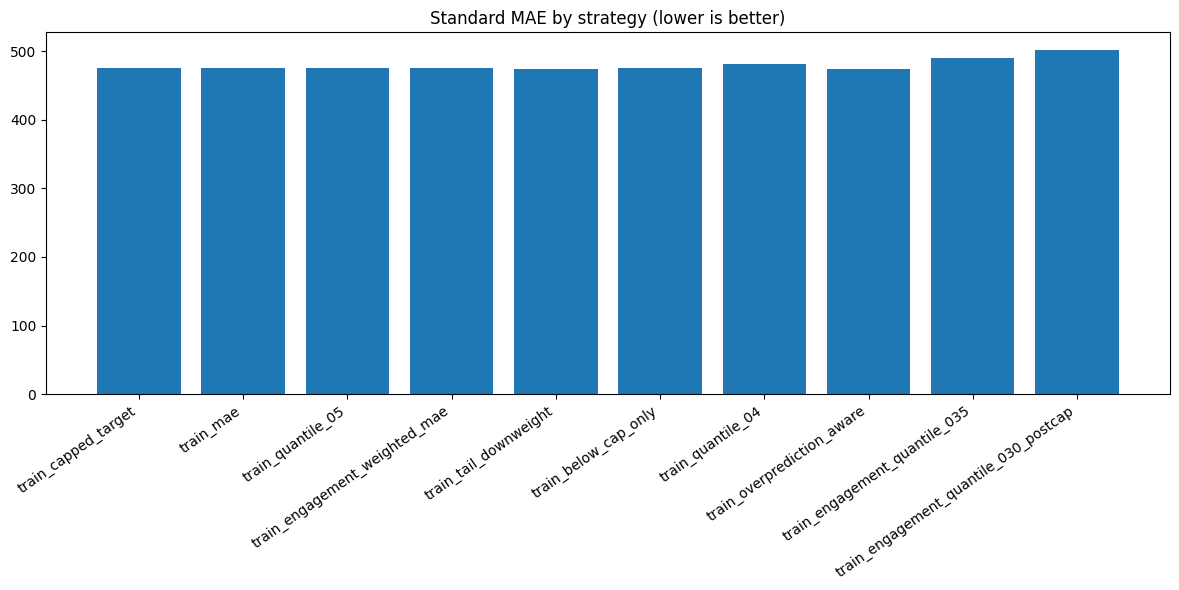

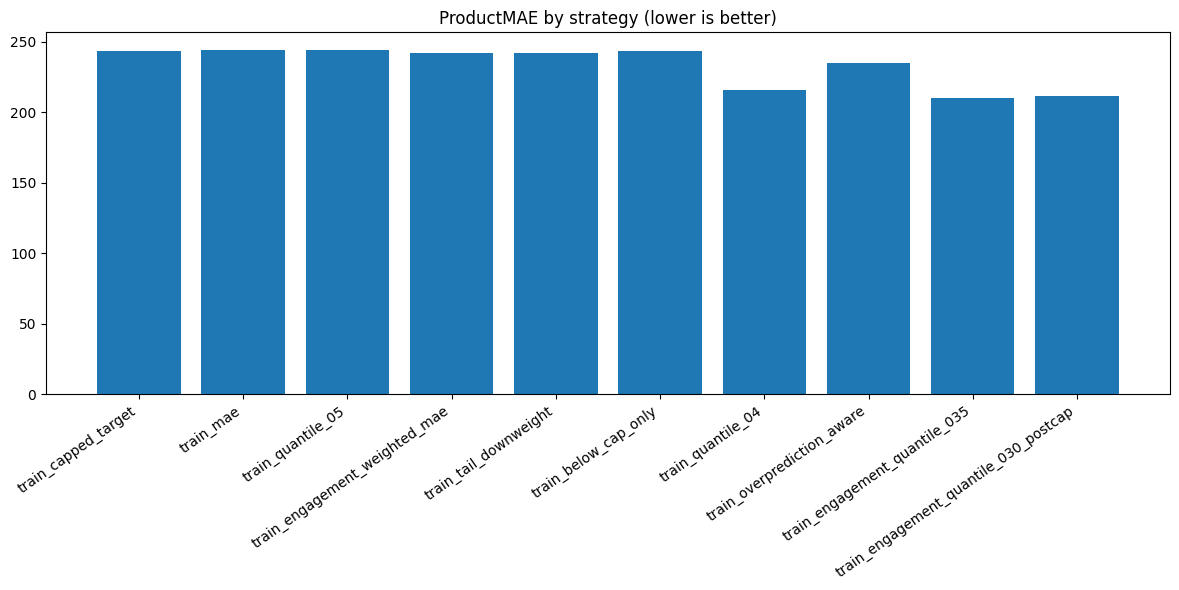

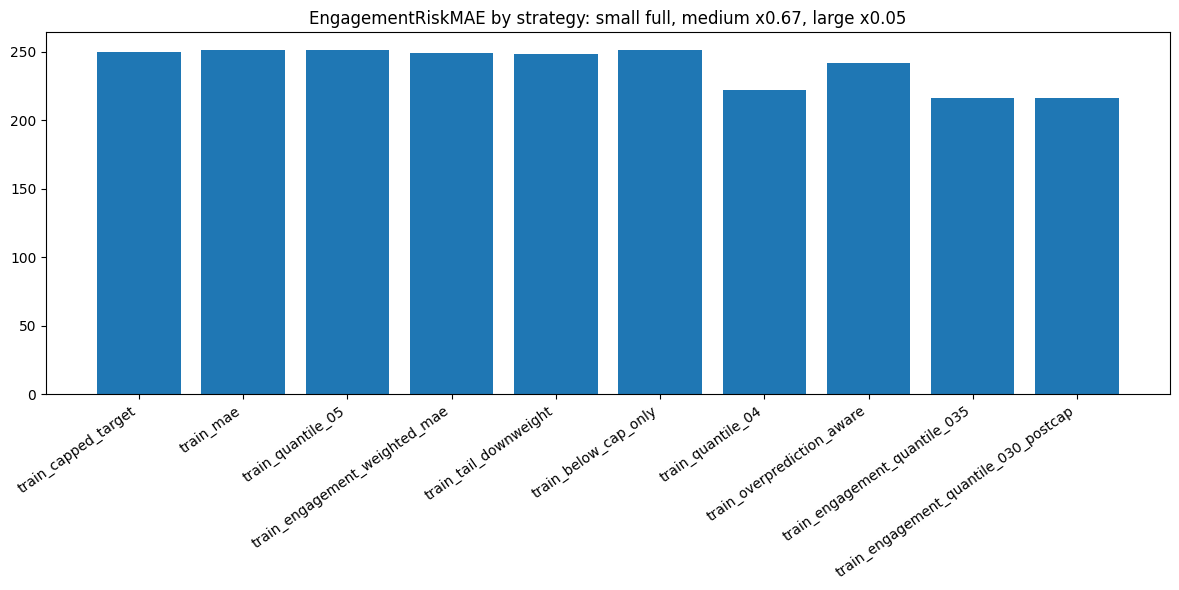

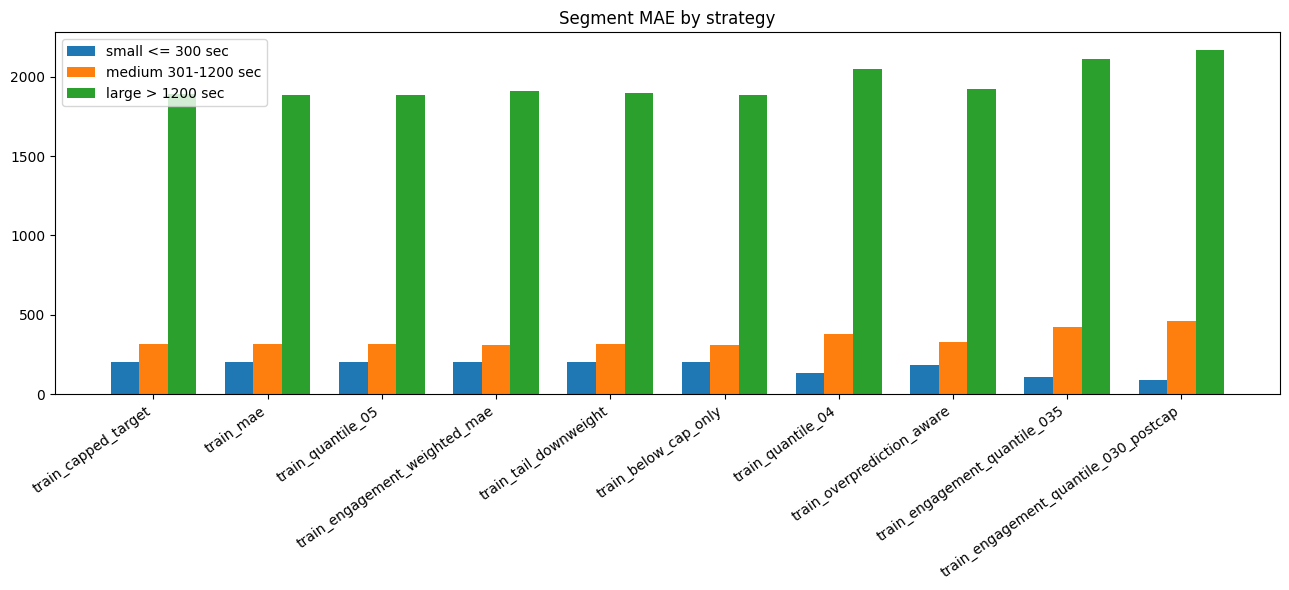

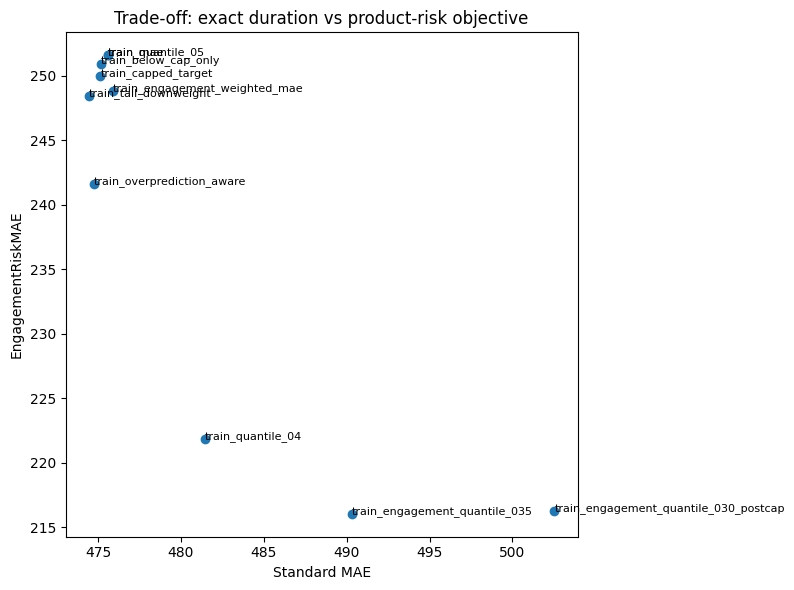

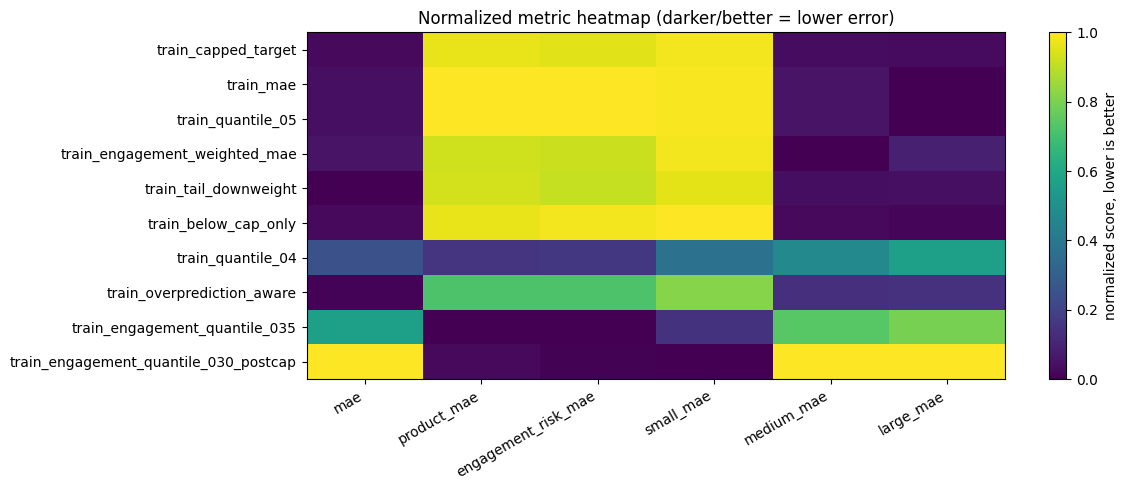

In [9]:
import matplotlib.pyplot as plt
# Графики стратегий в формате product_metric_lab
plot_target = 'target_next_session_length_sec'

z = res[res['target'] == plot_target].copy()
z = z.sort_values('test_mae').groupby('mode', as_index=False).first()

# Порядок как на графиках в lab
pref_order = [
    'train_capped_target',
    'train_mae',
    'train_quantile_05',
    'train_engagement_weighted_mae',
    'train_tail_downweight',
    'train_below_cap_only',
    'train_quantile_04',
    'train_overprediction_aware',
    'train_engagement_quantile_035',
    'train_engagement_quantile_030_postcap',
]
z['mode_rank'] = z['mode'].apply(lambda x: pref_order.index(x) if x in pref_order else 999)
z = z.sort_values('mode_rank').reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.bar(z['mode'], z['test_mae'])
plt.title('Standard MAE by strategy (lower is better)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(z['mode'], z['test_product_mae'])
plt.title('ProductMAE by strategy (lower is better)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(z['mode'], z['test_engagement_risk_mae'])
plt.title('EngagementRiskMAE by strategy: small full, medium x0.67, large x0.05')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

x = np.arange(len(z))
w = 0.25
plt.figure(figsize=(13, 6))
plt.bar(x - w, z['test_small_mae'], width=w, label='small <= 300 sec')
plt.bar(x, z['test_normal_mae'], width=w, label='medium 301-1200 sec')
plt.bar(x + w, z['test_long_mae'], width=w, label='large > 1200 sec')
plt.xticks(x, z['mode'], rotation=35, ha='right')
plt.title('Segment MAE by strategy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(z['test_mae'], z['test_engagement_risk_mae'])
for _, r in z.iterrows():
    plt.text(r['test_mae'], r['test_engagement_risk_mae'], r['mode'], fontsize=8)
plt.xlabel('Standard MAE')
plt.ylabel('EngagementRiskMAE')
plt.title('Trade-off: exact duration vs product-risk objective')
plt.tight_layout()
plt.show()

hm_cols = ['test_mae', 'test_product_mae', 'test_engagement_risk_mae', 'test_small_mae', 'test_normal_mae', 'test_long_mae']
hm = z.set_index('mode')[hm_cols].copy()
hm.columns = ['mae', 'product_mae', 'engagement_risk_mae', 'small_mae', 'medium_mae', 'large_mae']
# Нормализация так, чтобы lower error -> lower normalized
hmin = hm.min()
hmax = hm.max()
hn = (hm - hmin) / (hmax - hmin + 1e-12)

plt.figure(figsize=(12, 5))
plt.imshow(hn.values, aspect='auto', cmap='viridis')
plt.colorbar(label='normalized score, lower is better')
plt.yticks(np.arange(len(hn.index)), hn.index)
plt.xticks(np.arange(len(hn.columns)), hn.columns, rotation=30, ha='right')
plt.title('Normalized metric heatmap (darker/better = lower error)')
plt.tight_layout()
plt.show()


По обычному MAE различия между базовыми стратегиями небольшие: лучший результат показывает train_capped_target, рядом с ним идут train_mae, train_quantile_05, train_engagement_weighted_mae и train_tail_downweight. Более осторожные квантильные режимы постепенно ухудшают MAE, потому что специально смещают прогноз вниз и меньше пытаются точно предсказывать длинные сессии.

По продуктовым метрикам картина меняется: train_engagement_quantile_035 и train_engagement_quantile_030_postcap заметно снижают ProductMAE и EngagementRiskMAE, а train_quantile_04 дает промежуточный компромисс. При этом на сегментном графике можем увидеть логичный вывод: осторожные модели сильно улучшают ошибку на коротких сессиях, но хуже работают на средних и особенно длинных сессиях. То есть у нас в любом случае будет компромисс - или улучшать ошибку на коротких сессия, жертвуя остальными, или на средних и длинных, жертвуя короткми.

Для дальнейших экспериментов выбираем три метода: train_capped_target как основной кандидат с лучшим обычным MAE, train_quantile_04 как компромисс между точностью секунд и короткими сессиями, и train_engagement_quantile_035 как отдельную осторожную модель для продуктовых сценариев. 

## Лидеры по ключевым целям

Показываем разных лидеров для разных целей: общее качество, продуктовая ошибка, engagement риск и хвостовая ошибка.

In [ ]:
best_mae = res.sort_values('test_mae').groupby('target', as_index=False).first()
best_prod = res.sort_values('test_product_mae').groupby('target', as_index=False).first()
best_eng = res.sort_values('test_engagement_risk_mae').groupby('target', as_index=False).first()
best_tail = res.sort_values('test_tail_weighted_mae_q90_w2').groupby('target', as_index=False).first()

best_mae[['target', 'mode', 'test_mae', 'test_product_mae', 'test_engagement_risk_mae', 'test_wmape', 'test_tail_weighted_mae_q90_w2']]

,target,mode,test_mae,test_product_mae,test_engagement_risk_mae,test_wmape,test_tail_weighted_mae_q90_w2
0,future_sessions_mean_playtime_7d,train_tail_downweight,268.805451,200.624739,205.994999,0.466626,327.936131
1,target_next_session_length_sec,train_tail_downweight,474.445458,242.049036,248.430013,0.792005,639.836086


In [ ]:
best_prod[['target', 'mode', 'test_mae', 'test_product_mae', 'test_engagement_risk_mae', 'test_tail_weighted_mae_q90_w2']]

,target,mode,test_mae,test_product_mae,test_engagement_risk_mae,test_tail_weighted_mae_q90_w2
0,future_sessions_mean_playtime_7d,train_engagement_quantile_035,281.419299,190.875853,194.885298,353.678545
1,target_next_session_length_sec,train_engagement_quantile_035,490.820280,209.919639,216.070521,675.662449


In [ ]:
best_tail[['target', 'mode', 'test_tail_weighted_mae_q90_w2', 'test_mae', 'test_wmape', 'test_product_mae']]

,target,mode,test_tail_weighted_mae_q90_w2,test_mae,test_wmape,test_product_mae
0,future_sessions_mean_playtime_7d,train_tail_downweight,327.936131,268.805451,0.466626,200.624739
1,target_next_session_length_sec,train_mae,639.526220,475.568239,0.793880,244.359860


Ниче нового не узнали

## Нестабильность между val и test

Отдельно отмечаем режимы, где качество на валидации заметно лучше, чем на тесте. Это сигнал, что режим может быть слишком хрупким для реального продукта.

In [ ]:
tmp = res.copy()
tmp['delta_mae'] = tmp['test_mae'] - tmp['val_mae']
tmp['delta_product'] = tmp['test_product_mae'] - tmp['val_product_mae']
tmp['delta_eng'] = tmp['test_engagement_risk_mae'] - tmp['val_engagement_risk_mae']

tmp.sort_values(['target', 'delta_mae'], ascending=[True, False])[
    ['target', 'mode', 'depth', 'lr', 'l2', 'val_mae', 'test_mae', 'delta_mae', 'val_product_mae', 'test_product_mae', 'delta_product']
]

,target,mode,depth,lr,l2,val_mae,test_mae,delta_mae,val_product_mae,test_product_mae,delta_product
7,future_sessions_mean_playtime_7d,train_tail_downweight,5,0.06,3,275.948012,271.167804,-4.780208,192.730081,201.957644,9.227562
5,future_sessions_mean_playtime_7d,train_below_cap_only,5,0.06,3,275.629272,270.834887,-4.794385,193.771304,202.746044,8.974740
0,future_sessions_mean_playtime_7d,train_below_cap_only,6,0.05,5,274.354615,269.552671,-4.801944,191.838261,202.125608,10.287346
3,future_sessions_mean_playtime_7d,train_mae,6,0.05,5,274.779852,269.833491,-4.946360,192.777461,201.835123,9.057661
4,future_sessions_mean_playtime_7d,train_quantile_05,6,0.05,5,274.779852,269.833491,-4.946360,192.777461,201.835123,9.057661
2,future_sessions_mean_playtime_7d,train_capped_target,6,0.05,5,274.740319,269.086104,-5.654215,191.670946,201.367804,9.696857
1,future_sessions_mean_playtime_7d,train_tail_downweight,6,0.05,5,274.564576,268.805451,-5.759124,191.314624,200.624739,9.310115
8,future_sessions_mean_playtime_7d,train_mae,5,0.06,3,276.092802,270.195360,-5.897442,193.243385,201.644166,8.400780
9,future_sessions_mean_playtime_7d,train_quantile_05,5,0.06,3,276.092802,270.195360,-5.897442,193.243385,201.644166,8.400780
6,future_sessions_mean_playtime_7d,train_capped_target,5,0.06,3,275.897541,269.915371,-5.982170,192.373326,200.866025,8.492698


Здесь сильной нестабильности нет: для всех режимов test MAE не хуже, а даже ниже val MAE. Значит явного признака переобучения не видно